This Notebook deals with the Initial EDA for the data set.
I have used Pyspark for that purpose.

# Libraries:


This notebook deals with the part 1 of our Project
- I did the EDA and generated some plots using Pyspark and Pandas on the LA_crime_data set.
- This notebook gives the basis of the further analysis

In [6]:
import pandas,numpy

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, hour, month, year, when, count, desc, dayofmonth, to_date

# Data Import:

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize Spark with the Postgres driver
spark = SparkSession.builder \
    .appName("LA-Crime-Research") \
    .getOrCreate()
    
# Load the LA Crime CSV
df = spark.read.csv("CS226_project/Crime_Data.csv", header=True, inferSchema=True)
df.show(5)


+---------+--------------------+--------------------+--------+----+-----------+-----------+--------+------+--------------------+--------------------+--------+--------+------------+---------+--------------------+--------------+--------------------+------+-----------+--------+--------+--------+--------+--------------------+------------+-------+---------+
|    DR_NO|           Date Rptd|            DATE OCC|TIME OCC|AREA|  AREA NAME|Rpt Dist No|Part 1-2|Crm Cd|         Crm Cd Desc|             Mocodes|Vict Age|Vict Sex|Vict Descent|Premis Cd|         Premis Desc|Weapon Used Cd|         Weapon Desc|Status|Status Desc|Crm Cd 1|Crm Cd 2|Crm Cd 3|Crm Cd 4|            LOCATION|Cross Street|    LAT|      LON|
+---------+--------------------+--------------------+--------+----+-----------+-----------+--------+------+--------------------+--------------------+--------+--------+------------+---------+--------------------+--------------+--------------------+------+-----------+--------+--------+------

In [8]:
df.printSchema()

root
 |-- DR_NO: integer (nullable = true)
 |-- Date Rptd: string (nullable = true)
 |-- DATE OCC: string (nullable = true)
 |-- TIME OCC: integer (nullable = true)
 |-- AREA: integer (nullable = true)
 |-- AREA NAME: string (nullable = true)
 |-- Rpt Dist No: integer (nullable = true)
 |-- Part 1-2: integer (nullable = true)
 |-- Crm Cd: integer (nullable = true)
 |-- Crm Cd Desc: string (nullable = true)
 |-- Mocodes: string (nullable = true)
 |-- Vict Age: integer (nullable = true)
 |-- Vict Sex: string (nullable = true)
 |-- Vict Descent: string (nullable = true)
 |-- Premis Cd: integer (nullable = true)
 |-- Premis Desc: string (nullable = true)
 |-- Weapon Used Cd: integer (nullable = true)
 |-- Weapon Desc: string (nullable = true)
 |-- Status: string (nullable = true)
 |-- Status Desc: string (nullable = true)
 |-- Crm Cd 1: integer (nullable = true)
 |-- Crm Cd 2: integer (nullable = true)
 |-- Crm Cd 3: integer (nullable = true)
 |-- Crm Cd 4: integer (nullable = true)
 |-- L

In [9]:
df.count()

1004991

# Exploratory Data Analysis

### Data Cleaning:


In [10]:
# 1. Extract date time 
#----------------------------------

# Create a new column with just the Dates
df = df.withColumn("Date_Reported", to_date(col("Date Rptd"), "MM/dd/yyyy hh:mm:ss a"))
df = df.withColumn("Date_Occured", to_date(col("DATE OCC"), "MM/dd/yyyy hh:mm:ss a"))

# Extracting parts from the 'Date_Occured' column you just created
df = df.withColumn("Occured_Year", year("Date_Occured")) \
             .withColumn("Occured_Month", month("Date_Occured")) \
             .withColumn("Occured_Day", dayofmonth("Date_Occured"))
# Extracting parts from the 'Date_Occured' column you just created
df = df.withColumn("Reported_Year", year("Date_Reported")) \
             .withColumn("Reported_Month", month("Date_Reported")) \
             .withColumn("Reported_Day", dayofmonth("Date_Reported"))


# Show the results
df.select("Date_Occured", "Occured_Year", "Occured_Month", "Occured_Day").show(10)
df.select("Date_Reported", "Reported_Year", "Reported_Month", "Reported_Day").show(10)

df.show(5)

+------------+------------+-------------+-----------+
|Date_Occured|Occured_Year|Occured_Month|Occured_Day|
+------------+------------+-------------+-----------+
|  2020-11-07|        2020|           11|          7|
|  2020-10-18|        2020|           10|         18|
|  2020-10-30|        2020|           10|         30|
|  2020-12-24|        2020|           12|         24|
|  2020-09-29|        2020|            9|         29|
|  2020-11-11|        2020|           11|         11|
|  2020-04-16|        2020|            4|         16|
|  2020-07-07|        2020|            7|          7|
|  2020-03-02|        2020|            3|          2|
|  2020-09-01|        2020|            9|          1|
+------------+------------+-------------+-----------+
only showing top 10 rows

+-------------+-------------+--------------+------------+
|Date_Reported|Reported_Year|Reported_Month|Reported_Day|
+-------------+-------------+--------------+------------+
|   2021-04-11|         2021|             4|

In [11]:
# 2. Extract the hour (e.g., 1310 becomes 13)
df = df.withColumn("Hour", (col("TIME OCC") / 100).cast("int"))
df.show(5)


+---------+--------------------+--------------------+--------+----+-----------+-----------+--------+------+--------------------+--------------------+--------+--------+------------+---------+--------------------+--------------+--------------------+------+-----------+--------+--------+--------+--------+--------------------+------------+-------+---------+-------------+------------+------------+-------------+-----------+-------------+--------------+------------+----+
|    DR_NO|           Date Rptd|            DATE OCC|TIME OCC|AREA|  AREA NAME|Rpt Dist No|Part 1-2|Crm Cd|         Crm Cd Desc|             Mocodes|Vict Age|Vict Sex|Vict Descent|Premis Cd|         Premis Desc|Weapon Used Cd|         Weapon Desc|Status|Status Desc|Crm Cd 1|Crm Cd 2|Crm Cd 3|Crm Cd 4|            LOCATION|Cross Street|    LAT|      LON|Date_Reported|Date_Occured|Occured_Year|Occured_Month|Occured_Day|Reported_Year|Reported_Month|Reported_Day|Hour|
+---------+--------------------+--------------------+--------+--

## Analysis

1. Trend Analysis :Crime over time:
    * which year has more crimes going on?
    * which months have more crimes going on?
2. Top 10 Crime Descriptions
3. Crime by victim descent
4. Crime type vs Avg Age of the victim
5. Top 10 dangerous Areas and Premises for crime
6. Weapons vs crime

In [12]:
# 1. Crime Trend Analysis:

# Crimes per Year
df.groupBy("Occured_Year").count().orderBy("Occured_Year").show()

# Crimes per Month (Seasonality)
df.groupBy("Occured_Month").count().orderBy("Occured_Month").show()

+------------+------+
|Occured_Year| count|
+------------+------+
|        2020|199847|
|        2021|209876|
|        2022|235259|
|        2023|232345|
|        2024|127567|
|        2025|    97|
+------------+------+

+-------------+-----+
|Occured_Month|count|
+-------------+-----+
|            1|92701|
|            2|86401|
|            3|87818|
|            4|83518|
|            5|83013|
|            6|81382|
|            7|83962|
|            8|83850|
|            9|81015|
|           10|84127|
|           11|78978|
|           12|78226|
+-------------+-----+



In [13]:
# 2. Top 10 Crime Descriptions
df.groupBy("Crm Cd Desc").count().orderBy(desc("count")).show(10, truncate=False)

# 3. Crime by Victim Descent (Descent Code: H-Hispanic, W-White, B-Black, etc.)
df.groupBy("Vict Descent").count().orderBy(desc("count")).show()

# 4.Average age of victims per crime category
df.groupBy("Crm Cd Desc").avg("Vict Age").orderBy(desc("avg(Vict Age)")).show(10)

+-------------------------------------------------------+------+
|Crm Cd Desc                                            |count |
+-------------------------------------------------------+------+
|VEHICLE - STOLEN                                       |115190|
|BATTERY - SIMPLE ASSAULT                               |74839 |
|BURGLARY FROM VEHICLE                                  |63517 |
|THEFT OF IDENTITY                                      |62537 |
|VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)|61092 |
|BURGLARY                                               |57871 |
|THEFT PLAIN - PETTY ($950 & UNDER)                     |53717 |
|ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT         |53525 |
|INTIMATE PARTNER - SIMPLE ASSAULT                      |46712 |
|THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)        |41314 |
+-------------------------------------------------------+------+
only showing top 10 rows

+------------+------+
|Vict Descent| count|
+------------+------

In [14]:
# 5. Top 10 Dangerous Areas
df.groupBy("AREA NAME").count().orderBy(desc("count")).show(10)

# Most common premises for crime (Street, Apartment, Parking Lot, etc.)
df.groupBy("Premis Desc").count().orderBy(desc("count")).show(10, truncate=False)

+-----------+-----+
|  AREA NAME|count|
+-----------+-----+
|    Central|69670|
|77th Street|61758|
|    Pacific|59514|
|  Southwest|57441|
|  Hollywood|52429|
|N Hollywood|51107|
|    Olympic|50071|
|  Southeast|49936|
|     Newton|49177|
|   Wilshire|48239|
+-----------+-----+
only showing top 10 rows

+--------------------------------------------+------+
|Premis Desc                                 |count |
+--------------------------------------------+------+
|STREET                                      |261284|
|SINGLE FAMILY DWELLING                      |163654|
|MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)|119011|
|PARKING LOT                                 |69147 |
|OTHER BUSINESS                              |47647 |
|SIDEWALK                                    |40861 |
|VEHICLE, PASSENGER/TRUCK                    |29302 |
|GARAGE/CARPORT                              |19362 |
|DRIVEWAY                                    |16082 |
|DEPARTMENT STORE                            |

In [15]:
# 6. Weapons vs crime :

# Check for presence of weapon (Weapon_Used_Cd is not null)
df_weapon = df.withColumn("Has Weapon", when(col("Weapon Used Cd").isNotNull(), "Yes").otherwise("No"))

df_weapon.groupBy("Has Weapon").count().show()

# Top weapons used in crimes
df.filter(col("Weapon Desc").isNotNull()) \
    .groupBy("Weapon Desc").count() \
    .orderBy(desc("count")).show(10, truncate=False)

+----------+------+
|Has Weapon| count|
+----------+------+
|        No|677744|
|       Yes|327247|
+----------+------+

+----------------------------------------------+------+
|Weapon Desc                                   |count |
+----------------------------------------------+------+
|STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)|174761|
|UNKNOWN WEAPON/OTHER WEAPON                   |36390 |
|VERBAL THREAT                                 |23846 |
|HAND GUN                                      |20182 |
|SEMI-AUTOMATIC PISTOL                         |7267  |
|KNIFE WITH BLADE 6INCHES OR LESS              |6838  |
|UNKNOWN FIREARM                               |6582  |
|OTHER KNIFE                                   |5879  |
|MACE/PEPPER SPRAY                             |3730  |
|VEHICLE                                       |3260  |
+----------------------------------------------+------+
only showing top 10 rows



#### Plots

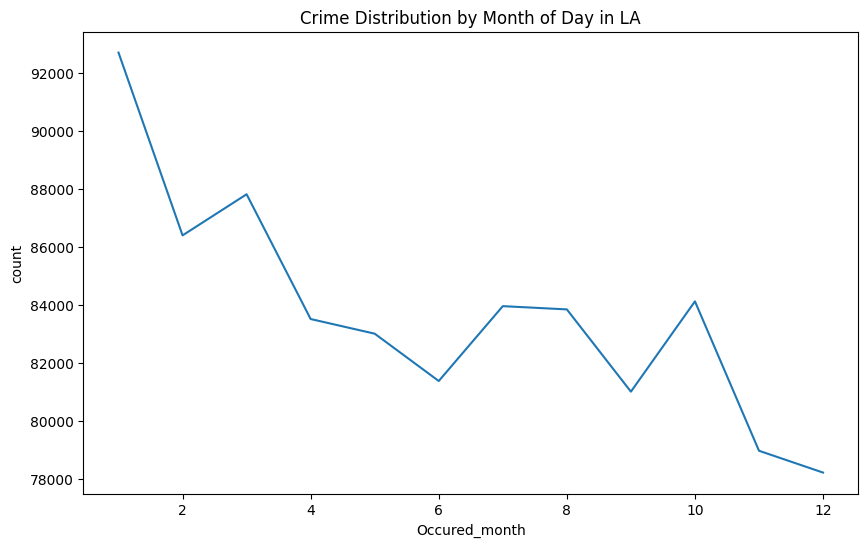

In [16]:

# Aggregate by Month for a line plot
monthly_crime = df.groupBy("Occured_month").count().orderBy("Occured_month").toPandas()

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_crime, x="Occured_month", y="count")
plt.title("Crime Distribution by Month of Day in LA")
plt.show()


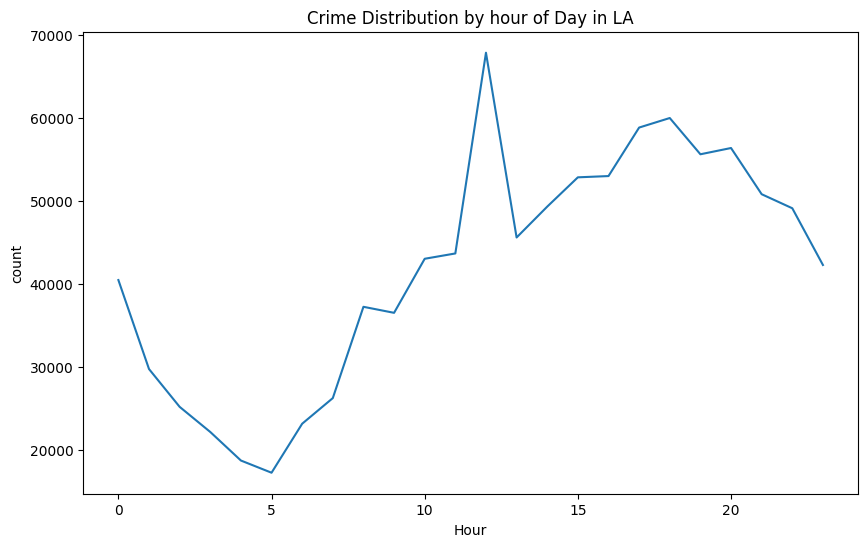

In [17]:

# Group by Hour and count occurrences
hourly_crime = df.groupBy("Hour").count().orderBy("Hour").toPandas()
plt.figure(figsize=(10,6))
sns.lineplot(data=hourly_crime, x="Hour", y="count")
plt.title("Crime Distribution by hour of Day in LA")
plt.show()

#### Spatial Plots


In [18]:
import geopandas
import folium
from folium.plugins import HeatMap
import branca.colormap as cm

# 1. Prepare your data (Sampled for performance)
map_data = df.select("LAT", "LON").filter("LAT != 0").limit(2000).toPandas()

# 2. Create the base map
m = folium.Map(location=[34.0522, -118.2437], zoom_start=11)

# 3. Define the Color Scale (Legend)
# Default HeatMap colors: Blue -> Green -> Yellow -> Orange -> Red
colormap = cm.LinearColormap(
    colors=['blue', 'lime', 'yellow', 'orange', 'red'],
    index=[0, 0.3, 0.5, 0.7, 1.0], # Density levels
    vmin=0,
    vmax=1,
    caption='Crime Density Intensity'
)

# 4. Add HeatMap and the Colormap to the map
HeatMap(map_data.values.tolist()).add_to(m)
m.add_child(colormap)

# 5. Save and view
m.save("crime_heatmap.html")
print("Open crime_heatmap.html in your browser to see the results!")

Open crime_heatmap.html in your browser to see the results!


# Data Cleaning and Save:

In [19]:
from pyspark.sql.functions import col, to_date, year, month, dayofmonth, when, trim
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize Spark with the Postgres driver
spark = SparkSession.builder \
    .appName("LA-Crime-Research") \
    .getOrCreate()
# 1. Load Data
df_crime = spark.read.csv("CS226_project/Crime_Data.csv", header=True, inferSchema=True)

# 2. Rename Columns (Standardize for SQL and Joining)
# This removes spaces like "Crm Cd Desc" -> "Crm_Cd_Desc"
for col_name in df_crime.columns:
    df_crime = df_crime.withColumnRenamed(col_name, col_name.replace(" ", "_"))

# 3. Standardize Dates
# Converts 'DATE_OCC' (MM/dd/yyyy hh:mm:ss a) to a proper Date type
df_crime = df_crime.withColumn("Date_Occured", to_date(col("DATE_OCC"), "MM/dd/yyyy hh:mm:ss a")) \
                   .withColumn("Date_Reported", to_date(col("Date_Rptd"), "MM/dd/yyyy hh:mm:ss a"))

# 4. Extract Temporal Features
df_crime = df_crime.withColumn("Occured_Year", year("Date_Occured")) \
                   .withColumn("Occured_Month", month("Date_Occured")) \
                   .withColumn("Occured_Day", dayofmonth("Date_Occured")) \
                   .withColumn("Hour", (col("TIME_OCC") / 100).cast("int"))

# 5. Geospatial & Demographic Cleaning
# Filter out 0/0 coordinates and invalid victim ages
df_crime_clean = df_crime.filter((col("LAT") != 0) & (col("LON") != 0)) \
                         .filter(col("Vict_Age") > 0)

# 6. Feature Engineering: Weapon Flag
df_crime_clean = df_crime_clean.withColumn(
    "Weapon_Used", 
    when(col("Weapon_Used_Cd").isNotNull(), "Yes").otherwise("No")
)



In [20]:
df_crime_clean.repartition(1).write.format("csv") \
    .option("header", "true") \
    .mode("overwrite") \
    .save("crime_cleaned_local.csv")

df_crime_clean.write.mode("overwrite").parquet("crime_cleaned_local.parquet")

26/03/05 00:50:46 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/03/05 00:50:46 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/03/05 00:50:46 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/03/05 00:50:46 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/03/05 00:50:46 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/03/05 00:50:47 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/03/05 00:50:47 WARN MemoryManager: Total allocation exceeds 95.